# Roadkill EDA (2012+)

Goals of this section:
1. Clean the observations (coordinates, dates, duplicates), restrict to **2012+**, and label each
   record with the 1-mile highway segment it falls on.
2. Counts by year, source, species, month, and highway.
3. Hotspots: records per 1-mile highway/milepost segment.

In [1]:
import urllib.request
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

DATA = Path('../data')
EXT = DATA / 'external'
EXT.mkdir(parents=True, exist_ok=True)

START_YEAR = 2012

# Chart palette (validated categorical order; blue sequential ramp)
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
INK, INK_2, MUTED, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': INK_2, 'axes.titlecolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
    'axes.grid.axis': 'y', 'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'legend.frameon': False, 'font.size': 9,
})

## 1. Cleaning

Observations:

* **Dates**: `observed` is stored as a UTC timestamp but almost all records are date-only (`00:00:00+00`). Converting to local time would shift those back a day, so the calendar date is taken as written.
* **Coordinates**: `latitude`/`longitude` are **swapped** for nearly all *ITD Survey 123* records (and some *ITD Roadkill Import*). The Web Mercator `X`/`Y` columns are correct for every record, so lat/lon are recomputed from `X`/`Y`.
* **No location**: *ITD Roadkill Import* records have no coordinates at all, only highway + milepost. They can be used for road-segment counts but not the spatial analysis (they could be geocoded later against ITD's milepost layer).
* **Out of state**: a few hundred records geocode outside Idaho (typos, other states). Dropped from spatial analysis using the Census state boundary (1 km buffer so border highways are kept).
* **Duplicates**: some submissions are identical in every field except the system IDs; these are treated as double submissions and removed. Records at the same place/date that differ in sex, age, or notes are kept (multiple animals).

In [2]:
raw = pd.read_csv(DATA / 'roadkill_observations.csv', low_memory=False)

raw['obs_date'] = pd.to_datetime(raw['observed'].str[:10], format='%Y/%m/%d', errors='coerce')
raw['year'] = raw['obs_date'].dt.year
raw['month'] = raw['obs_date'].dt.month

# Web Mercator (EPSG:3857) -> WGS84
R = 6378137.0
raw['lon'] = np.degrees(raw['X'] / R)
raw['lat'] = np.degrees(2 * np.arctan(np.exp(raw['Y'] / R)) - np.pi / 2)

swapped = raw['latitude'].between(-117.3, -111.0) & raw['longitude'].between(41.9, 49.1)
print('Records with swapped latitude/longitude, by source:')
raw.loc[swapped, 'source'].value_counts()

Records with swapped latitude/longitude, by source:


source
ITD Survey 123         1462
ITD Roadkill Import      18
Name: count, dtype: int64

In [3]:
states_zip = EXT / 'cb_2023_us_state_500k.zip'
if not states_zip.exists():
    urllib.request.urlretrieve('https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_500k.zip', states_zip)

idaho = gpd.read_file(states_zip).query("STUSPS == 'ID'")[['NAME', 'geometry']]
idaho_buffered = idaho.to_crs(5070).buffer(1000).to_crs(4326).union_all()

In [4]:
def species_group(name):
    if name.startswith(('Mule Deer', 'White-tailed Deer', 'Deer (')):
        return 'Deer'
    for group in ('Elk', 'Moose'):
        if name.startswith(group):
            return group
    return 'Other'

id_cols = {'OBJECTID', 'GlobalID', 'path', 'X', 'Y', 'lat', 'lon'}
recent = raw[raw['year'] >= START_YEAR].copy()
recent[['year', 'month']] = recent[['year', 'month']].astype(int)
is_dup = recent.duplicated(subset=[c for c in recent.columns if c not in id_cols])

rk = recent[~is_dup].copy()
rk['species_group'] = rk['species'].fillna('Unknown').map(species_group)
rk['has_coords'] = rk['lon'].notna()
rk['in_idaho'] = gpd.GeoSeries(gpd.points_from_xy(rk['lon'], rk['lat']), index=rk.index, crs=4326).within(idaho_buffered)

# Normalise route names; free-text entries ("Hwy 95", "Chinden") are ambiguous (US vs ID routes) and left unassigned
route = rk['highway'].str.strip().str.upper()
rk['route'] = route.where(route.str.match(r'^(I|US|ID)-\d+[A-Z]?$'))

# 1-mile segment each record falls on: route + floor(milepost). NA when either field is missing.
rk['mp'] = np.floor(rk['milepost']).astype('Int64').where(rk['route'].notna())
rk['segment'] = rk['route'] + ' MP ' + rk['mp'].astype('string') + '–' + (rk['mp'] + 1).astype('string')

pd.Series({
    'All records in file': len(raw),
    f'Observed {START_YEAR} or later': len(recent),
    'Exact duplicate submissions removed': int(is_dup.sum()),
    'Analysis records': len(rk),
    '  with coordinates': int(rk['has_coords'].sum()),
    '  with coordinates inside Idaho (spatial analysis)': int(rk['in_idaho'].sum()),
    '  with a standard route + milepost (segment analysis)': int(rk['segment'].notna().sum()),
}).to_frame('records')

,records
All records in file,68793
Observed 2012 or later,53078
Exact duplicate submissions removed,546
Analysis records,52532
with coordinates,51090
with coordinates inside Idaho (spatial analysis),50811
with a standard route + milepost (segment analysis),22936


### Saving the cleaned dataset

`rk` is written to `data/processed/roadkill_clean_2012plus.parquet` so the modelling notebooks can
skip the cleaning above. It carries the derived columns used below — `obs_date`/`year`/`month`,
corrected `lat`/`lon`, `species_group`, `in_idaho`, `route`, `mp` and the `segment` label. Object
columns are cast to `string` first (`path` is mixed-type in the raw file).

In [5]:
PROC = DATA / 'processed'
PROC.mkdir(exist_ok=True)
clean_path = PROC / f'roadkill_clean_{START_YEAR}plus.parquet'

clean = rk.astype({c: 'string' for c in rk.columns if rk[c].dtype == 'object'})
clean.to_parquet(clean_path, index=False, compression='zstd')

print(f'{len(clean):,} rows x {clean.shape[1]} cols -> {clean_path} '
      f'({clean_path.stat().st_size / 1e6:.1f} MB)')
pd.read_parquet(clean_path).dtypes.to_frame('dtype').T

52,532 rows x 34 cols -> ../data/processed/roadkill_clean_2012plus.parquet (5.3 MB)


,X,Y,OBJECTID,species,source,observed,salvaged,sex,lifeStage,lifeState,disposition,decomposition,latitude,longitude,highway,milepost,note,reported,county,region,gmu,path,GlobalID,obs_date,year,month,lon,lat,species_group,has_coords,in_idaho,route,mp,segment
dtype,float64,float64,int64,str,str,str,str,str,str,str,str,str,float64,float64,str,float64,str,str,float64,float64,float64,str,str,datetime64[us],int64,int64,float64,float64,str,bool,bool,str,Int64,str


## 2. Counts (2012+)

In [6]:
span = f"{rk['obs_date'].min():%Y-%m-%d} to {rk['obs_date'].max():%Y-%m-%d}"
print(f'{len(rk):,} records, {span} (2025 is a partial year)')

by_year_source = pd.crosstab(rk['year'], rk['source'], margins=True, margins_name='Total')
by_year_source

52,532 records, 2012-01-01 to 2025-11-19 (2025 is a partial year)


source,Big Game Mortality Report (BGMR),IDFG Roadkill & Salvage Reports,IDFG Survey 123,ITD Roadkill Import,ITD Survey 123,Total
year,,,,,,
2012,1,3682,0,0,0,3683
2013,1,3686,0,0,0,3687
2014,4,4499,0,0,0,4503
2015,7,4867,0,0,0,4874
2016,5,3733,0,0,0,3738
2017,5,3551,0,0,0,3556
2018,21,4214,0,0,0,4235
2019,10,4487,0,0,0,4497
2020,15,3466,0,751,97,4329


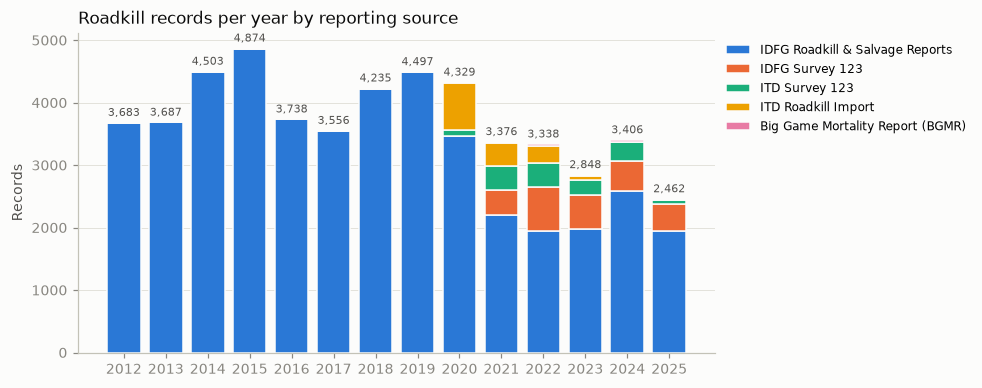

In [7]:
source_order = rk['source'].value_counts().index.tolist()
yearly = pd.crosstab(rk['year'], rk['source'])[source_order]

fig, ax = plt.subplots(figsize=(9, 3.6))
bottom = np.zeros(len(yearly))
for color, src in zip(SERIES, source_order):
    ax.bar(yearly.index, yearly[src], bottom=bottom, color=color, width=0.8,
           edgecolor='#fcfcfb', linewidth=1, label=src)
    bottom += yearly[src].values
for x, total in zip(yearly.index, bottom):
    ax.text(x, total + 60, f'{int(total):,}', ha='center', va='bottom', fontsize=7.5, color=INK_2)
ax.set_title('Roadkill records per year by reporting source', loc='left')
ax.set_ylabel('Records')
ax.set_xticks(yearly.index)
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=8)
plt.tight_layout()
plt.show()

Reporting effort is not constant: *IDFG Roadkill & Salvage Reports* (public salvage reports) fall after 2019, while ITD/IDFG Survey123 apps start in 2020. Year-to-year changes are at least partly **changes in reporting**, not in collisions

In [8]:
species_counts = rk['species'].value_counts().head(15).to_frame('records')
species_counts['share_%'] = (100 * species_counts['records'] / len(rk)).round(1)
species_counts

,records,share_%
species,,
White-tailed Deer (Odocoileus virginianus),18730,35.7
Mule Deer (Odocoileus hemionus),17131,32.6
Elk (Cervus canadensis),5151,9.8
Moose (Alces alces),1555,3.0
Common Raccoon (Procyon lotor),995,1.9
Domestic Cat (Felis catus),815,1.6
Coyote (Canis latrans),517,1.0
Skunks and Stink Badgers (Mephitidae),508,1.0
North American Porcupine (Erethizon dorsatum),481,0.9


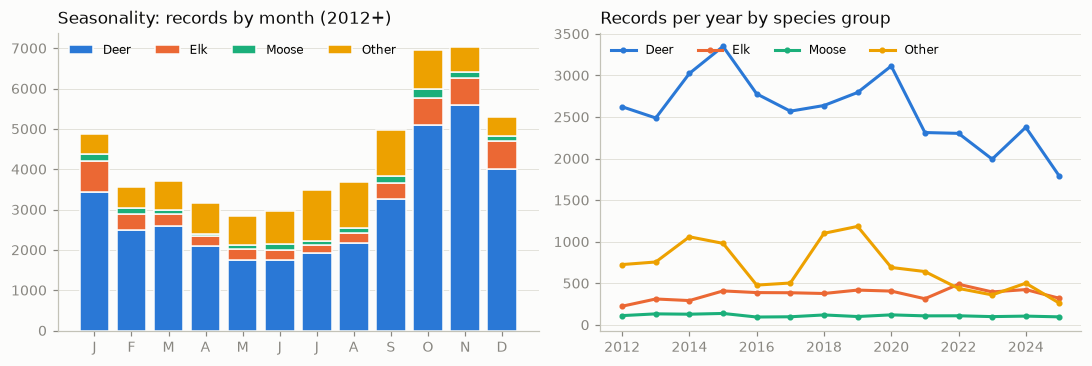

month,1,2,3,4,5,6,7,8,9,10,11,12
species_group,,,,,,,,,,,,
Deer,3423,2492,2597,2088,1751,1740,1918,2179,3255,5101,5597,4009
Elk,781,404,293,254,263,267,207,244,414,655,671,698
Moose,168,132,88,54,109,142,104,110,155,235,131,127
Other,498,538,720,756,707,825,1246,1162,1154,969,630,471
Total,4870,3566,3698,3152,2830,2974,3475,3695,4978,6960,7029,5305


In [9]:
group_order = ['Deer', 'Elk', 'Moose', 'Other']
monthly = pd.crosstab(rk['month'], rk['species_group'])[group_order]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
bottom = np.zeros(12)
for color, g in zip(SERIES, group_order):
    axes[0].bar(monthly.index, monthly[g], bottom=bottom, color=color, width=0.8,
                edgecolor='#fcfcfb', linewidth=1, label=g)
    bottom += monthly[g].values
axes[0].set_xticks(range(1, 13), ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
axes[0].set_title('Seasonality: records by month (2012+)', loc='left')
axes[0].legend(ncols=4, loc='upper left', fontsize=8)

group_year = pd.crosstab(rk['year'], rk['species_group'])[group_order]
for color, g in zip(SERIES, group_order):
    axes[1].plot(group_year.index, group_year[g], color=color, linewidth=2, marker='o', markersize=3, label=g)
axes[1].set_title('Records per year by species group', loc='left')
axes[1].legend(ncols=4, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

monthly.assign(Total=monthly.sum(axis=1)).T

In [10]:
located = rk.groupby('year').agg(
    records=('OBJECTID', 'size'),
    pct_with_route=('route', lambda s: round(100 * s.notna().mean(), 1)),
    pct_in_idaho=('in_idaho', lambda s: round(100 * s.mean(), 1)),
)
located

,records,pct_with_route,pct_in_idaho
year,,,
2012,3683,79.8,99.9
2013,3687,74.2,100.0
2014,4503,70.7,99.7
2015,4874,68.3,99.7
2016,3738,55.2,99.2
2017,3556,51.5,98.2
2018,4235,48.5,99.3
2019,4497,44.4,99.7
2020,4329,43.2,82.4


The share of records with a highway + milepost falls from ~80% in 2012 to 0% in 2025 — the current reporting forms capture GPS coordinates instead. Any road-segment model must therefore **snap records to a road network by coordinates** rather than relying on the `highway`/`milepost` fields.

In [11]:
route_counts = (
    rk.dropna(subset=['route'])
    .groupby('route')
    .agg(records=('OBJECTID', 'size'),
         deer=('species_group', lambda s: (s == 'Deer').sum()),
         elk=('species_group', lambda s: (s == 'Elk').sum()),
         moose=('species_group', lambda s: (s == 'Moose').sum()))
    .sort_values('records', ascending=False)
)
route_counts.head(20)

,records,deer,elk,moose
route,,,,
US-95,6828,4782,370,169
US-20,1886,530,180,58
US-12,1697,1312,18,3
US-2,1249,1141,40,22
US-93,1108,675,193,6
I-15,875,589,100,31
US-30,868,650,146,7
ID-75,772,502,172,4
ID-3,732,555,50,12


## 3. Hotspots: 1-mile highway segments

Segment = route + `floor(milepost)`. Only records with a standard route name and a milepost are included (44% of 2012+ records, mostly 2012–2020), so this view is biased toward state highways and toward the earlier years.

In [12]:
n_years = (rk['obs_date'].max() - rk['obs_date'].min()).days / 365.25

segments = rk.dropna(subset=['segment']).groupby(['route', 'mp', 'segment'], as_index=False).agg(
    records=('OBJECTID', 'size'),
    years_with_records=('year', 'nunique'),
    deer=('species_group', lambda s: (s == 'Deer').sum()),
    elk=('species_group', lambda s: (s == 'Elk').sum()),
    moose=('species_group', lambda s: (s == 'Moose').sum()),
    lat=('lat', 'median'),
    lon=('lon', 'median'),
)
segments['per_year'] = (segments['records'] / n_years).round(1)
segments = segments.sort_values('records', ascending=False).reset_index(drop=True)

print(f"{len(segments):,} segments have ≥1 record; "
      f"top 1% of segments hold {segments['records'].head(len(segments) // 100).sum() / segments['records'].sum():.0%} of records")
segments.head(25)[['segment', 'records', 'per_year', 'years_with_records', 'deer', 'elk', 'moose', 'lat', 'lon']]

3,381 segments have ≥1 record; top 1% of segments hold 10% of records


,segment,records,per_year,years_with_records,deer,elk,moose,lat,lon
0,ID-16 MP 13–14,118,8.5,7,30,0,0,43.861230,-116.499399
1,US-95 MP 514–515,112,8.1,12,99,10,0,48.780953,-116.297756
2,US-95 MP 498–499,99,7.1,13,96,1,1,48.580642,-116.386292
3,US-95 MP 515–516,95,6.8,13,85,8,0,48.793400,-116.305198
4,US-95 MP 509–510,91,6.6,13,85,6,0,48.714956,-116.307627
5,US-95 MP 512–513,91,6.6,10,86,1,0,48.757680,-116.288259
6,US-95 MP 513–514,89,6.4,13,85,2,0,48.768707,-116.292887
7,US-2 MP 67–68,89,6.4,11,87,0,1,48.730468,-116.238129
8,US-95 MP 501–502,84,6.1,12,82,2,0,48.617165,-116.354350
9,US-2 MP 68–69,80,5.8,12,80,0,0,48.727963,-116.221015


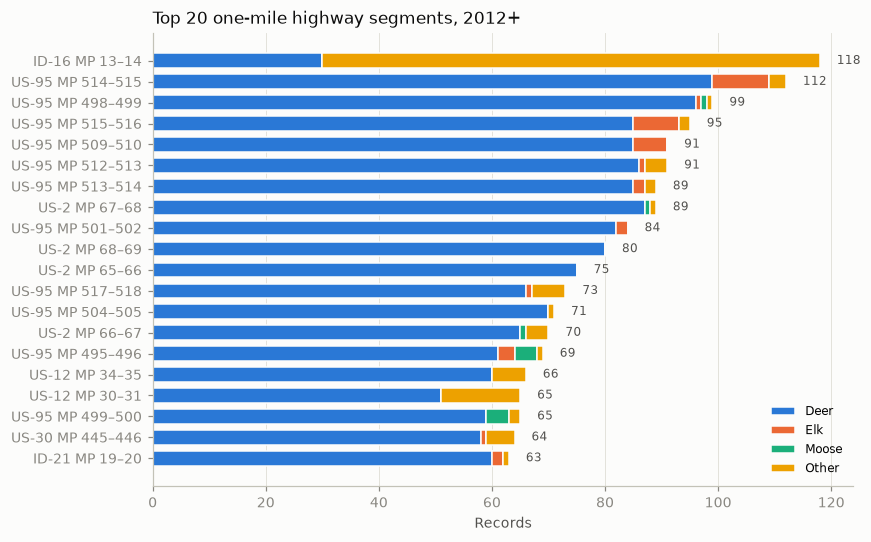

In [13]:
top = segments.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
left = np.zeros(len(top))
for color, g in zip(SERIES, ['deer', 'elk', 'moose']):
    ax.barh(top['segment'], top[g], left=left, color=color, height=0.7, edgecolor='#fcfcfb', linewidth=1, label=g.title())
    left += top[g].values
other = top['records'] - left
ax.barh(top['segment'], other, left=left, color=SERIES[3], height=0.7, edgecolor='#fcfcfb', linewidth=1, label='Other')
for y, total in enumerate(top['records']):
    ax.text(total + 3, y, f'{total}', va='center', fontsize=8, color=INK_2)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_title('Top 20 one-mile highway segments, 2012+', loc='left')
ax.set_xlabel('Records')
ax.legend(ncols=1, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**Caution** The #1 segment, ID-16 MP 13–14 (Emmett area), has 118 records, every
one an IDFG salvage report from 2012–2018 (7 of the 14 years) and three quarters of them small
animals- badger (25), domestic cat (19), skunk (9)- with only 30 deer. That pattern suggests one
diligent reporter rather than an exceptional collision rate. The US-95 (Bonners Ferry–Sandpoint),
US-2 and US-12 segments, by contrast, are 78–100% deer and have records in 10–13 of the 14 years,
which is a much more robust signal. "Years with records" is a useful sanity filter.